# 18 — Client visit summary (headline view)

One row per visit, combining identity, payment, first-visit completion %, and diagnostic risk flags into a single view — the kind of object a notebook or dashboard would `SELECT * FROM`. Mirrors `docs/clientQueries.md` §3.5.

The view itself lives in `sql/views/v_client_visit_summary.sql`; this notebook just runs the headline query against it.

In [1]:
import pandas as pd
from db import get_engine

engine = get_engine()

In [2]:
query = """
SELECT * FROM v_client_visit_summary
WHERE visit_type = '1'
ORDER BY pct_sections_complete DESC;
"""

df = pd.read_sql(query, engine)
print(df)

    client_id                     name     surname   country  visit_id  \
0         145           localErrorDiet      change        RO        65   
1          24                    Edith        Piaf        FR         6   
2         144  localSevereFibromialgia     display        ES        64   
3         143        localFibromialgia     changed        RO        63   
4         141         LFibromialgyaIMG        mini        RO        61   
5         130                 GigiMini         mac   Romania        52   
6         133               fiscalVode     Italian        IT        54   
7         138               cardiac219      change        RO        58   
8          37                     Emma     Marrone        IT         1   
9         122         SubcutaneousMini         mac   Italian        37   
10        123      Test_02.04.26.11.14        User        IT        38   
11        124              macMiniTest         dev  American        39   
12        127                    diet1

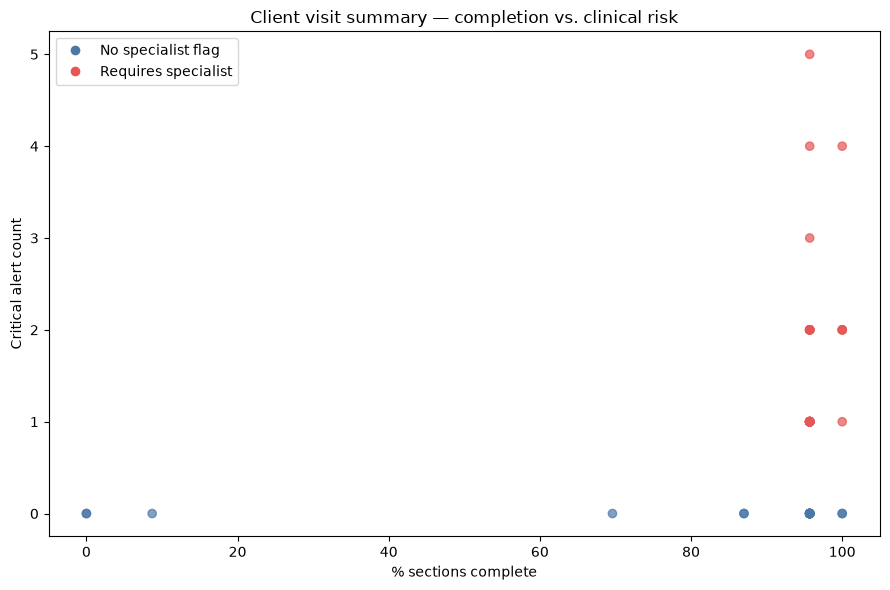

In [3]:
%matplotlib inline
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

flagged = df["requires_specialist"].fillna(0).astype(int)
point_colors = flagged.map({0: "#4C78A8", 1: "#E45756"})

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df["pct_sections_complete"], df["critical_alert_count"].fillna(0), c=point_colors, alpha=0.7)
ax.set_xlabel("% sections complete")
ax.set_ylabel("Critical alert count")
ax.set_title("Client visit summary \u2014 completion vs. clinical risk")

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#4C78A8", markersize=8, label="No specialist flag"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#E45756", markersize=8, label="Requires specialist"),
]
ax.legend(handles=legend_elements)
fig.tight_layout()

os.makedirs("../assets/img", exist_ok=True)
fig.savefig("../assets/img/client_visit_summary.png", dpi=150)
plt.show()